excess data in 'kern' subtable: 6 bytes
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


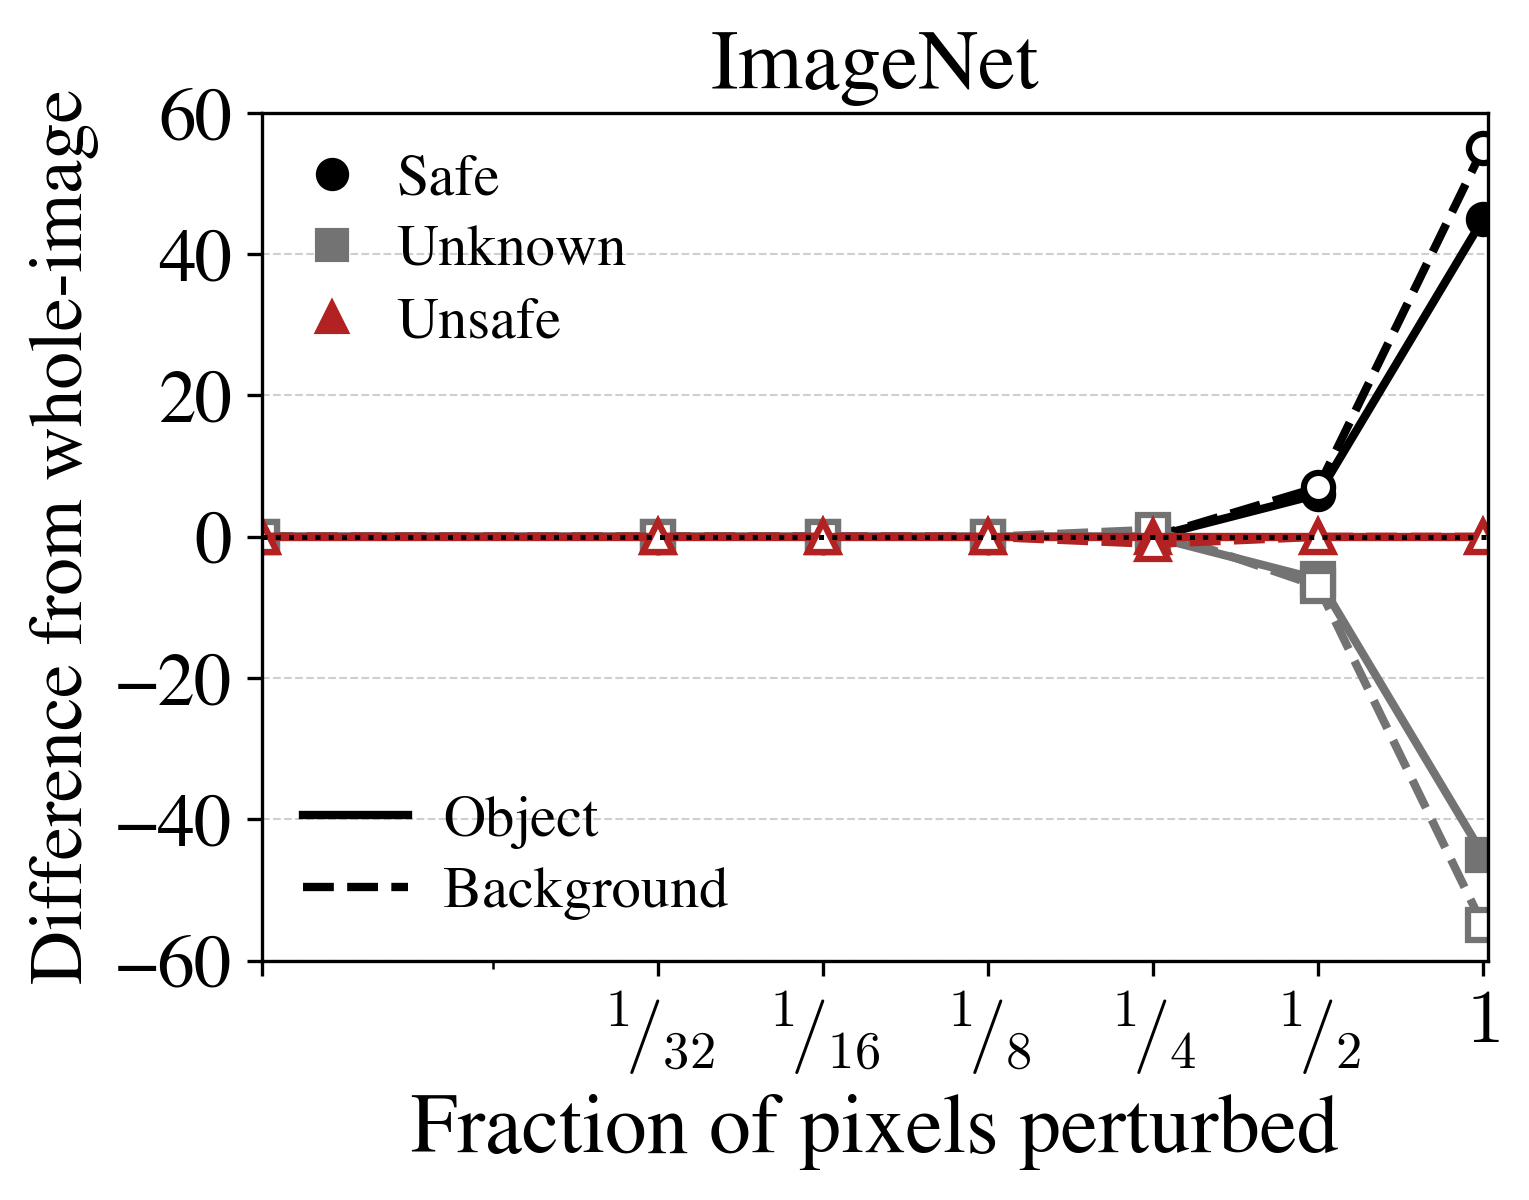

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

plt.rcParams.update({
    "font.family": "times",
    "mathtext.fontset": "cm",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

label_fs = 20
tick_fs = 18
legend_fs = 14

x_vals = np.array([1 / 32, 1 / 16, 1 / 8, 1 / 4, 1 / 2, 1], dtype=float)
x_plot_vals = np.concatenate(([0.0], x_vals))
x_tick_vals = x_plot_vals
x_labels = [
    "",
    r"$^{1}\!/_{32}$",
    r"$^{1}\!/_{16}$",
    r"$^{1}\!/_{8}$",
    r"$^{1}\!/_{4}$",
    r"$^{1}\!/_{2}$",
    r"$1$",
]

series = {
    ("Safe", "Object"): [0, 0, 0, 0, 6, 45],
    ("Safe", "Background"): [0, 0, 0, 0, 7, 55],
    ("Unknown", "Object"): [0, 0, 0, 0, -6, -45],
    ("Unknown", "Background"): [0, 0, 0, 1, -7, -55],
    ("Unsafe", "Object"): [0, 0, 0, 0, 0, 0],
    ("Unsafe", "Background"): [0, 0, 0, -1, 0, 0],
}

outcome_style = {
    "Safe": {"color": "black", "marker": "o"},
    "Unknown": {"color": "0.45", "marker": "s"},
    "Unsafe": {"color": "#B22222", "marker": "^"},
}

region_style = {
    "Object": {"linestyle": "-", "markerfacecolor": None},
    "Background": {"linestyle": "--", "markerfacecolor": "white"},
}

def plot_l0(ax):
    for (outcome, region), values in series.items():
        markerfacecolor = outcome_style[outcome]["color"]
        if region_style[region]["markerfacecolor"] is not None:
            markerfacecolor = region_style[region]["markerfacecolor"]

        ax.plot(
            x_plot_vals,
            np.concatenate(([0.0], values)),
            linewidth=2.0,
            color=outcome_style[outcome]["color"],
            linestyle=region_style[region]["linestyle"],
            marker=outcome_style[outcome]["marker"],
            markersize=7.0,
            markerfacecolor=markerfacecolor,
            markeredgecolor=outcome_style[outcome]["color"],
            markeredgewidth=1.5,
        )

    all_values = np.array([value for values in series.values() for value in values], dtype=float)
    y_limit = np.max(np.abs(all_values)) + 5
    y_ticks = np.arange(-y_limit, y_limit + 1, 20)

    ax.set_xscale("symlog", linthresh=x_vals[0] / 2, linscale=0.7, base=2)
    ax.set_xticks(x_tick_vals)
    ax.set_xticklabels(x_labels)
    ax.set_xlim(0.0, 1.02)

    ax.axhline(y=0.0, color="black", linestyle=":", linewidth=1.2)
    ax.set_xlabel("Fraction of pixels perturbed", fontsize=label_fs)
    ax.set_ylabel("Difference from whole-image", fontsize=label_fs - 2)
    ax.set_ylim(-y_limit, y_limit)
    ax.set_yticks(y_ticks)
    ax.tick_params(axis="both", labelsize=tick_fs)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)


fig, ax = plt.subplots(figsize=(5.2, 4.1), dpi=300)


plot_l0(ax)

ax.set_title("ImageNet", fontsize=label_fs)

outcome_handles = [
    Line2D(
        [0],
        [0],
        color=style["color"],
        marker=style["marker"],
        linestyle="None",
        markersize=7.0,
        markerfacecolor=style["color"],
        markeredgecolor=style["color"],
        label=outcome,
    )
    for outcome, style in outcome_style.items()
]

region_handles = [
    Line2D(
        [0],
        [0],
        color="black",
        linestyle=style["linestyle"],
        linewidth=2.0,
        label=region,
    )
    for region, style in region_style.items()
]

outcome_legend = ax.legend(
    handles=outcome_handles,
    frameon=False,
    loc="upper left",
    fontsize=legend_fs,
    handlelength=1.0,
    handletextpad=0.6,
    labelspacing=0.3,
    borderpad=0.2,
)
ax.add_artist(outcome_legend)

ax.legend(
    handles=region_handles,
    frameon=False,
    loc="lower left",
    fontsize=legend_fs,
    handlelength=1.8,
    handletextpad=0.6,
    labelspacing=0.3,
    borderpad=0.2,
)

fig.tight_layout()
fig.savefig("imagenet_l0_semantic_vs_global.pdf", bbox_inches="tight")
plt.show()

excess data in 'kern' subtable: 6 bytes
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


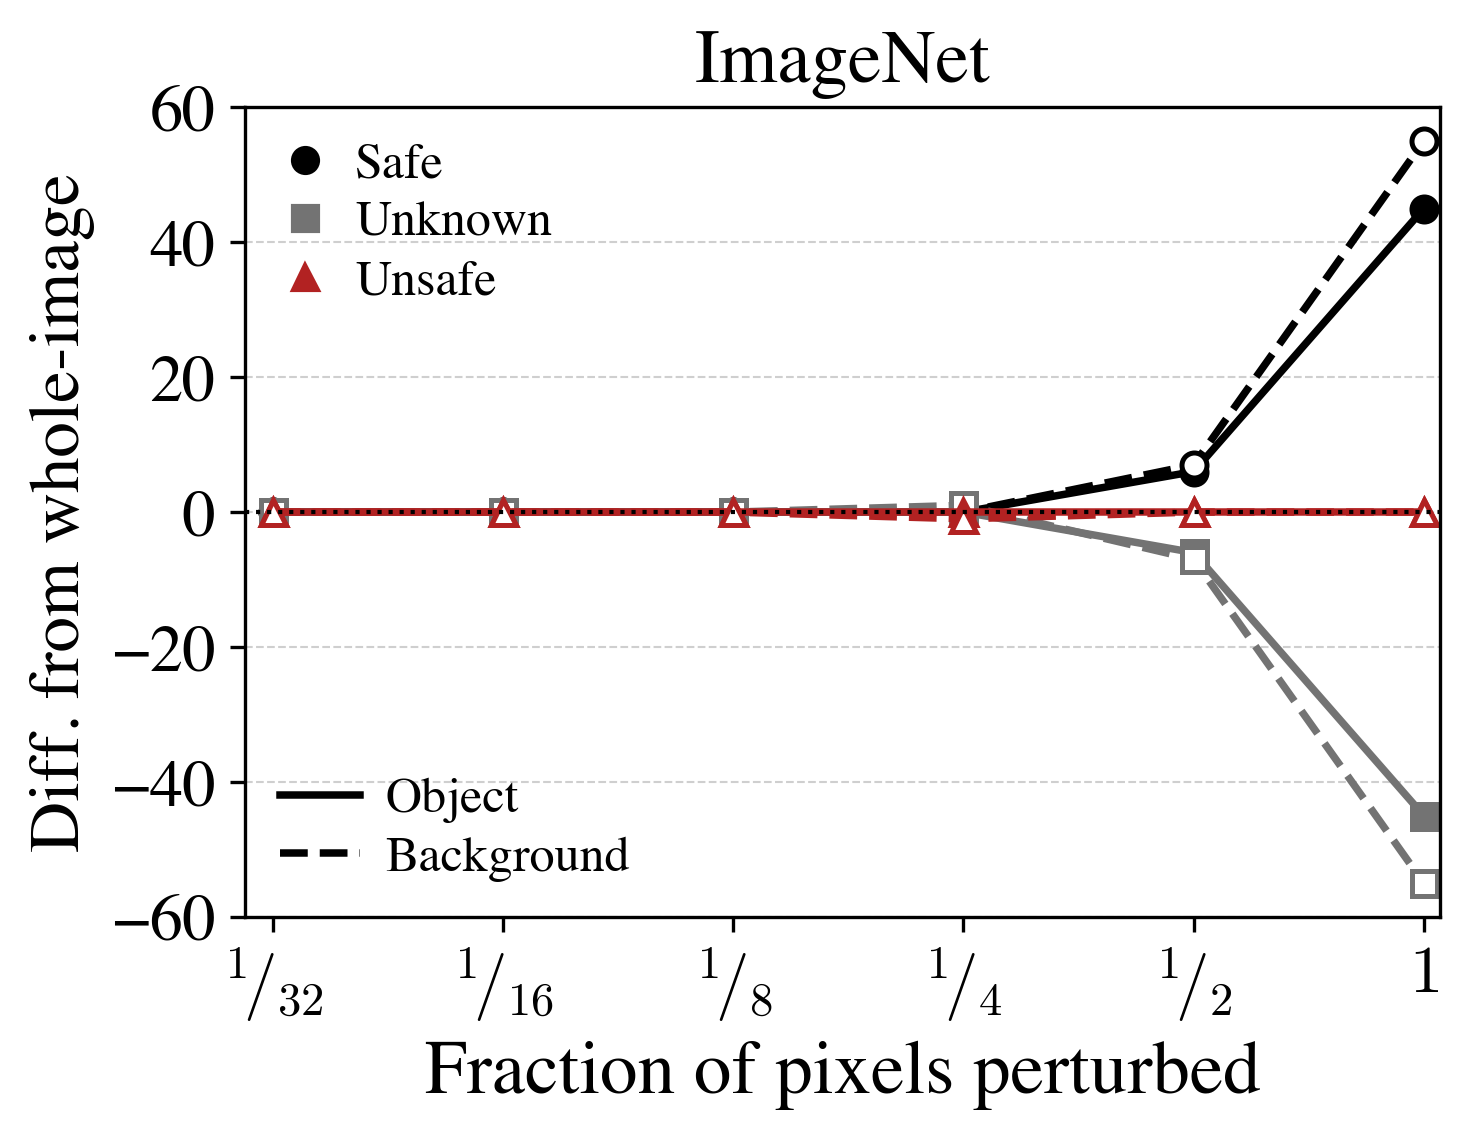

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

plt.rcParams.update({
    "font.family": "times",
    "mathtext.fontset": "cm",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

label_fs = 18
tick_fs = 16
legend_fs = 12
title_fs = 18

x_vals = np.array([1 / 32, 1 / 16, 1 / 8, 1 / 4, 1 / 2, 1], dtype=float)
x_labels = [
    r"$^{1}\!/_{32}$",
    r"$^{1}\!/_{16}$",
    r"$^{1}\!/_{8}$",
    r"$^{1}\!/_{4}$",
    r"$^{1}\!/_{2}$",
    r"$1$",
]

series = {
    ("Safe", "Object"): [0, 0, 0, 0, 6, 45],
    ("Safe", "Background"): [0, 0, 0, 0, 7, 55],
    ("Unknown", "Object"): [0, 0, 0, 0, -6, -45],
    ("Unknown", "Background"): [0, 0, 0, 1, -7, -55],
    ("Unsafe", "Object"): [0, 0, 0, 0, 0, 0],
    ("Unsafe", "Background"): [0, 0, 0, -1, 0, 0],
}

outcome_style = {
    "Safe": {"color": "black", "marker": "o"},
    "Unknown": {"color": "0.45", "marker": "s"},
    "Unsafe": {"color": "#B22222", "marker": "^"},
}

region_style = {
    "Object": {"linestyle": "-", "markerfacecolor": None},
    "Background": {"linestyle": "--", "markerfacecolor": "white"},
}

def plot_l0(ax):
    for (outcome, region), values in series.items():
        markerfacecolor = outcome_style[outcome]["color"]
        if region_style[region]["markerfacecolor"] is not None:
            markerfacecolor = region_style[region]["markerfacecolor"]

        ax.plot(
            x_vals,
            values,
            linewidth=1.8,
            color=outcome_style[outcome]["color"],
            linestyle=region_style[region]["linestyle"],
            marker=outcome_style[outcome]["marker"],
            markersize=6.0,
            markerfacecolor=markerfacecolor,
            markeredgecolor=outcome_style[outcome]["color"],
            markeredgewidth=1.2,
        )

    all_values = np.array([value for values in series.values() for value in values], dtype=float)
    y_limit = np.max(np.abs(all_values)) + 5
    y_ticks = np.arange(-y_limit, y_limit + 1, 20)

    ax.set_xscale("log", base=2)
    ax.set_xticks(x_vals)
    ax.set_xticklabels(x_labels)
    ax.set_xlim(x_vals[0] * 0.92, 1.05)

    ax.axhline(y=0.0, color="black", linestyle=":", linewidth=1.0)
    ax.set_xlabel("Fraction of pixels perturbed", fontsize=label_fs)
    ax.set_ylabel("Diff. from whole-image", fontsize=label_fs - 1)
    ax.set_ylim(-y_limit, y_limit)
    ax.set_yticks(y_ticks)
    ax.tick_params(axis="both", labelsize=tick_fs)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)


fig, ax = plt.subplots(figsize=(5.0, 3.9), dpi=300)

plot_l0(ax)

ax.set_title("ImageNet", fontsize=title_fs)

outcome_handles = [
    Line2D(
        [0],
        [0],
        color=style["color"],
        marker=style["marker"],
        linestyle="None",
        markersize=6.0,
        markerfacecolor=style["color"],
        markeredgecolor=style["color"],
        label=outcome,
    )
    for outcome, style in outcome_style.items()
]

region_handles = [
    Line2D(
        [0],
        [0],
        color="black",
        linestyle=style["linestyle"],
        linewidth=1.8,
        label=region,
    )
    for region, style in region_style.items()
]

outcome_legend = ax.legend(
    handles=outcome_handles,
    frameon=False,
    loc="upper left",
    fontsize=legend_fs,
    handlelength=1.0,
    handletextpad=0.5,
    labelspacing=0.25,
    borderpad=0.2,
)
ax.add_artist(outcome_legend)

ax.legend(
    handles=region_handles,
    frameon=False,
    loc="lower left",
    fontsize=legend_fs,
    handlelength=1.6,
    handletextpad=0.5,
    labelspacing=0.25,
    borderpad=0.2,
)

fig.tight_layout()
fig.savefig("imagenet_l0_semantic_vs_global.pdf", bbox_inches="tight")
plt.show()